In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt

from insolation_model.raster import Raster
from insolation_model.insolation import insolation_coefficient
from insolation_model import vis

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from tests.test_data.context import dem_path

dem = Raster.from_tif(dem_path).in_utm()

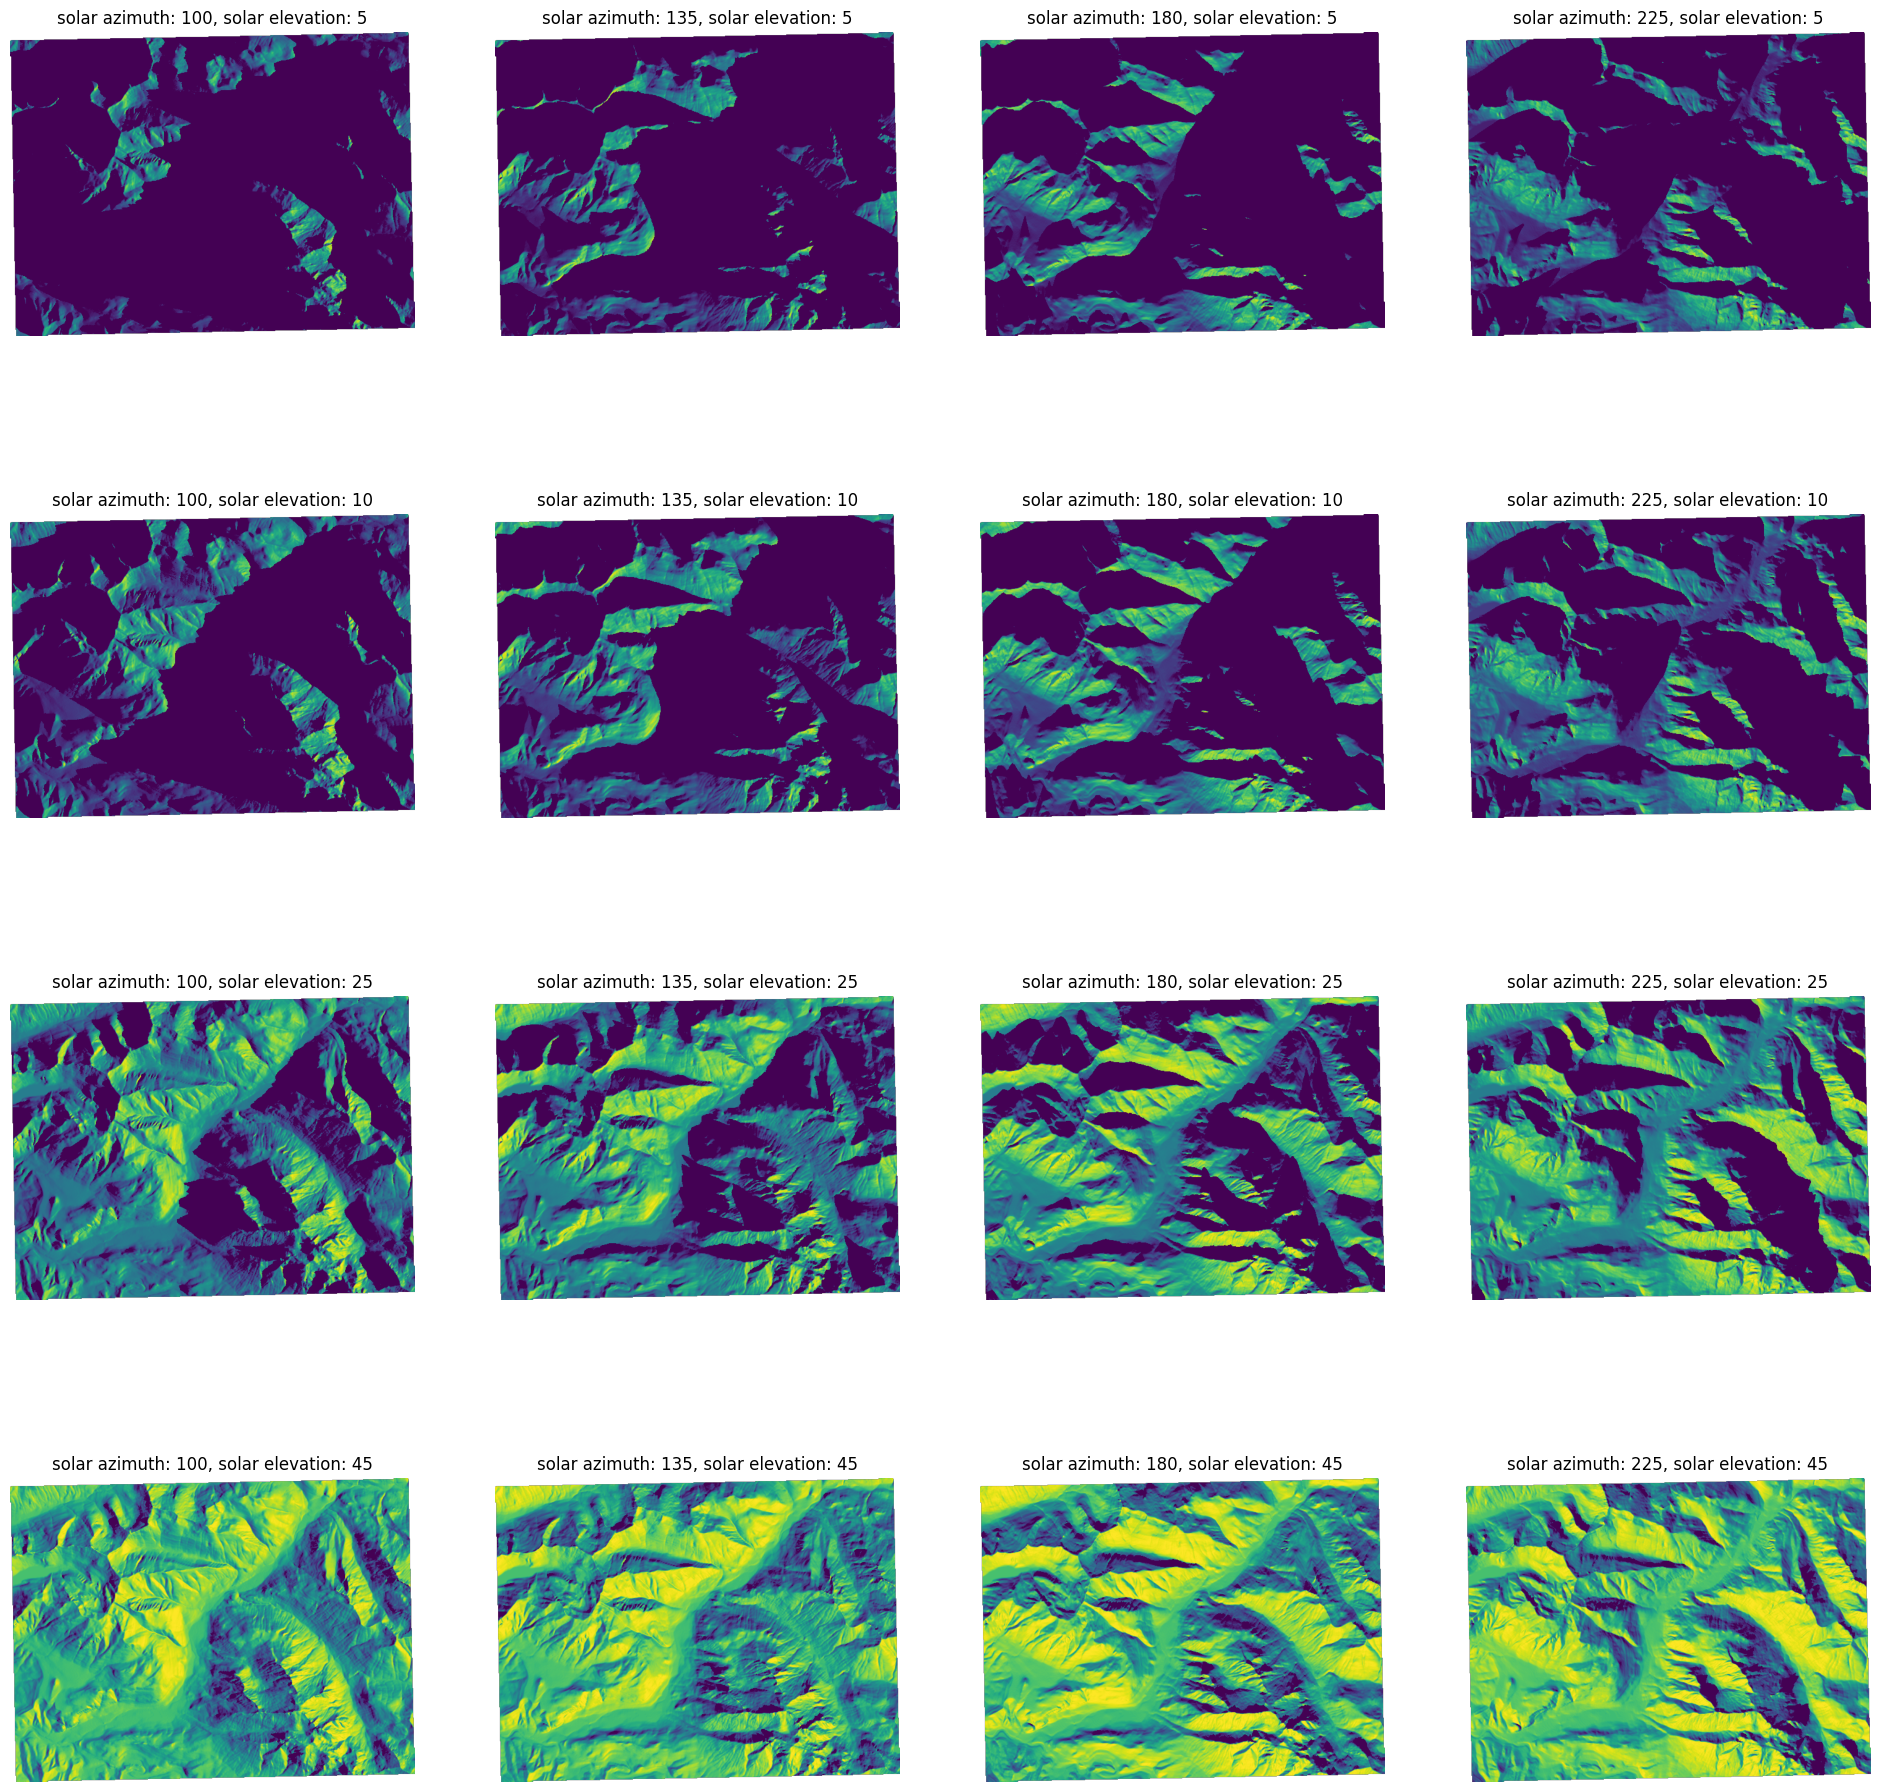

In [2]:
solar_elevations = [5, 10, 25, 45]
solar_azimuths = [100, 135, 180, 225]

n_rows = len(solar_elevations)
n_cols = len(solar_azimuths)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 6 * n_rows))

for i, solar_elevation in enumerate(solar_elevations):
    for j, solar_azimuth in enumerate(solar_azimuths):
        ax = axes[i, j]
        ax.set_title(
            f"solar azimuth: {solar_azimuth}, solar elevation: {solar_elevation}"
        )
        insolation = dem.with_array(
            insolation_coefficient(dem, solar_azimuth, solar_elevation)
        )
        vis.raster(insolation, ax=ax, vmin=0, vmax=1)
        ax.set_axis_off()